In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Model


import tensorflow as tf
from tensorflow.keras.layers import Lambda, Dense, Input, Dropout, Embedding, LSTM

In [2]:
def encode_objects(df):
    for col, dtype in df.dtypes.items():
        if dtype == 'object' and col != 'label':
            encoder = LabelEncoder()
            df[col] = encoder.fit_transform(df[col])
    return df

In [3]:
columns = ["duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent",
        "hot", "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root", 
        "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
        "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
        "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count", 
        "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
        "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label"]

df_init = pd.read_csv("datasets/kddcup1999/kddcup.data.corrected", sep=",", names=columns, index_col=None)

# Pre-processing

In [4]:
# Keeping only the features selected in the paper A stacking... by Smitha Rajagopal

keep_cols = ['logged_in', 'count', 'dst_host_count', 'protocol_type', 'srv_count', 'dst_host_same_src_port_rate', 'srv_diff_host_rate', 'dst_bytes', 'serror_rate', 'srv_serror_rate', 'same_srv_rate', 'flag', 'dst_host_same_srv_rate', 'dst_host_srv_count', 'dst_host_srv_diff_host_rate', 'label']

df_feature_selected = df_init[df_init.columns.intersection(keep_cols)]

In [5]:
df_feature_selected_encoded = encode_objects(df_feature_selected)

df_feature_selected_encoded['label'] = df_feature_selected_encoded['label'].apply(lambda x: 0 if x=='normal.' else 1)

df_feature_selected_encoded = df_feature_selected_encoded.drop(df_feature_selected_encoded[df_feature_selected_encoded['dst_bytes'] > 2e8].index)
df_feature_selected_encoded

C:\Users\David\AppData\Local\Temp\ipykernel_29396\847671518.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = encoder.fit_transform(df[col])
C:\Users\David\AppData\Local\Temp\ipykernel_29396\847671518.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = encoder.fit_transform(df[col])
C:\Users\David\AppData\Local\Temp\ipykernel_29396\4107281012.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value

,protocol_type,flag,dst_bytes,logged_in,count,srv_count,serror_rate,srv_serror_rate,same_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,label
0,1,9,45076,1,1,1,0.0,0.0,1.0,0.00,0,0,0.0,0.00,0.00,0
1,1,9,4528,1,2,2,0.0,0.0,1.0,0.00,1,1,1.0,1.00,0.00,0
2,1,9,1228,1,1,1,0.0,0.0,1.0,0.00,2,2,1.0,0.50,0.00,0
3,1,9,2032,1,2,2,0.0,0.0,1.0,0.00,3,3,1.0,0.33,0.00,0
4,1,9,486,1,3,3,0.0,0.0,1.0,0.00,4,4,1.0,0.25,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4898426,1,9,2288,1,3,32,0.0,0.0,1.0,0.16,3,255,1.0,0.33,0.05,0
4898427,1,9,236,1,4,33,0.0,0.0,1.0,0.15,4,255,1.0,0.25,0.05,0
4898428,1,9,3610,1,5,34,0.0,0.0,1.0,0.15,5,255,1.0,0.20,0.05,0
4898429,1,9,1234,1,6,35,0.0,0.0,1.0,0.14,6,255,1.0,0.17,0.05,0


In [6]:
normal = df_feature_selected_encoded.query('label == 0').sample(100000)
attack = df_feature_selected_encoded.query('label == 1').sample(500)


In [7]:
# Conduct a train-test split    
train, test = train_test_split(normal, test_size=0.2, random_state=42)

y_train = train['label']
x_train = train.drop('label', axis=1)

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

test = pd.concat([test, attack]).sample(frac=1)
y_test = test['label']
x_test = test.drop('label', axis=1)

print("Shapes")
print(f"x_train:{x_train.shape}\ny_train:{y_train.shape}")
print(f"\nx_train:{x_val.shape}\ny_train:{y_val.shape}")
print(f"\nx_test:{x_test.shape}\ny_test:{y_test.shape}")

Shapes
x_train:(64000, 15)
y_train:(64000,)

x_train:(16000, 15)
y_train:(16000,)

x_test:(20500, 15)
y_test:(20500,)


## Scaling features

In [8]:
scaler = StandardScaler()
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

# Model

In [9]:
%load_ext tensorboard
%tensorboard --logdir logs/autoencoder_kdd/

Reusing TensorBoard on port 6006 (pid 23540), started 1 day, 12:40:01 ago. (Use '!kill 23540' to kill it.)

In [10]:
BATCH_SIZE = 64
EPOCHS = 100
input_dim = x_train_scaled.shape[1]
intermediate_dim = [8, 4]
latent_dim = 3

# encoder
inputs = Input(shape=(input_dim, ), name='encoder_input')
for index in range(len(intermediate_dim)):
    if index == 0:
        x = Dense(intermediate_dim[index], activation='relu')(inputs)
    else:
        x = Dense(intermediate_dim[index], activation='relu')(x)
z = Dense(latent_dim, activation='relu', name='z')(x)

encoder = Model(inputs, z, name='encoder')
encoder.summary()

# decoder
latent_inputs = Input(shape=(latent_dim, ), name='z_sampling')
for index in reversed(range(len(intermediate_dim))):
    if index == len(intermediate_dim) - 1:
        x = Dense(intermediate_dim[index], activation='relu')(latent_inputs)
    else:
        x = Dense(intermediate_dim[index], activation='relu')(x)
outputs = Dense(input_dim, activation='sigmoid')(x)

decoder = Model(latent_inputs, outputs, name='decoder')
decoder.summary()

outputs = decoder(encoder(inputs))
autoencoder = Model(inputs, outputs, name='autoencoder')

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ z (Dense)                       │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 179 (716.00 B)

 Trainable params: 179 (716.00 B)

 Non-trainable params: 0 (0.00 B)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_sampling (InputLayer)         │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 15)             │           135 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 191 (764.00 B)

 Trainable params: 191 (764.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
autoencoder.compile(optimizer="adam", 
                    loss="mse",
                    metrics=["acc"])

# print an overview of our model
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 3)              │           179 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 15)             │           191 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 370 (1.45 KB)

 Trainable params: 370 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from datetime import datetime

# current date and time
yyyymmddHHMM = datetime.now().strftime('%Y%m%d%H%M')

# new folder for a new run
log_subdir = f'{yyyymmddHHMM}_batch{BATCH_SIZE}_layers{len(autoencoder.layers)}'

# define our early stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.001,
    patience=5,
    verbose=1, 
    mode='min',
    restore_best_weights=True
)

save_model = tf.keras.callbacks.ModelCheckpoint(
    filepath='models/autoencoder_kdd_best_weights.keras', 
    save_best_only=True,
    monitor='val_loss',
    verbose=0,
    mode='min'
)

tensorboard = tf.keras.callbacks.TensorBoard(
    f'logs/autoencoder_kdd/{log_subdir}',
    update_freq='batch'
)

# callbacks argument only takes a list
cb = [early_stop, save_model, tensorboard]

## Training

In [13]:
history = autoencoder.fit(
    x_train_scaled, x_train_scaled,
    shuffle=True,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb,
    validation_data=(x_val_scaled, x_val_scaled)
)

Epoch 1/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.2174 - loss: 1.0565 - val_acc: 0.3664 - val_loss: 0.9183
Epoch 2/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - acc: 0.3718 - loss: 0.8580 - val_acc: 0.4371 - val_loss: 0.8996
Epoch 3/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.4786 - loss: 0.8180 - val_acc: 0.5243 - val_loss: 0.8936
Epoch 4/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.5366 - loss: 0.8213 - val_acc: 0.5346 - val_loss: 0.8851
Epoch 5/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.5408 - loss: 0.8452 - val_acc: 0.5344 - val_loss: 0.8833
Epoch 6/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.5461 - loss: 0.8328 - val_acc: 0.5394 - val_loss: 0.8739
Epoch 7/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.5427 - loss: 0.8067 - val_acc: 0.5236 - val_loss: 0.8716
Epoch 8/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.5276 - loss: 0.8477 - val_acc: 0.5049 - val_loss: 0.8705
Epoch 9/100
1000/1000 ━━━━━━━━━━

# Predictions using only encoder

In [14]:
encoded_normal_data = encoder.predict(x_train_scaled)
encoded_data = encoder.predict(x_test_scaled)

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 2s 789us/step
641/641 ━━━━━━━━━━━━━━━━━━━━ 1s 798us/step


In [15]:
centroid = np.mean(encoded_normal_data, axis=0)
distances = pairwise_distances(encoded_data, [centroid], metric='euclidean')

# Set a threshold and classify anomalies
threshold = np.percentile(distances, 80)  # for example, set threshold at 95th percentile
anomalies = distances > threshold
threshold

29.855273056030274

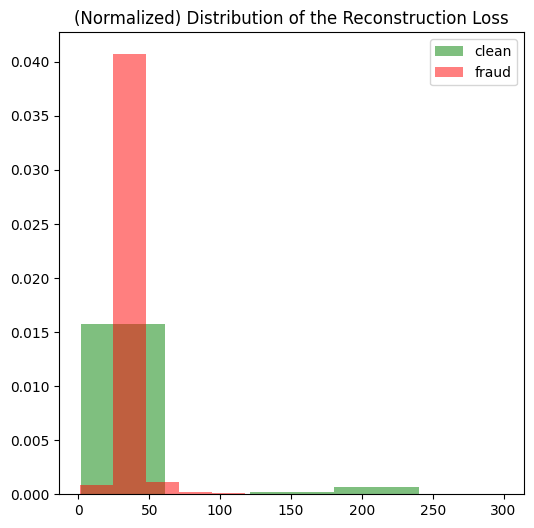

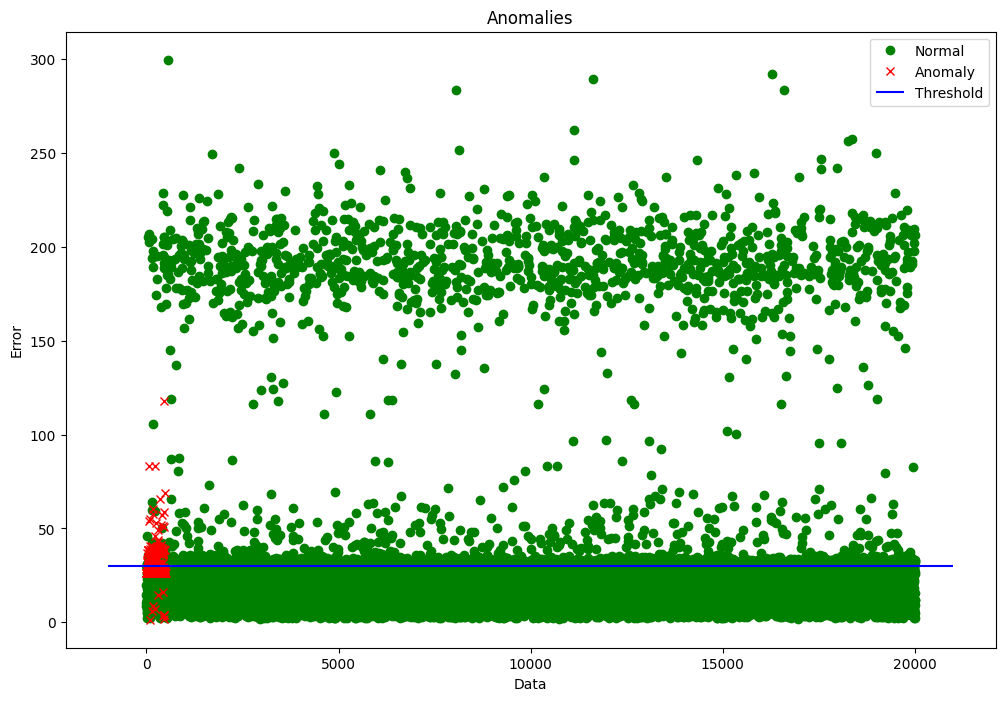

In [16]:
clean = distances[y_test==0]
fraud = distances[y_test==1]

fig, ax = plt.subplots(figsize=(6,6))

ax.hist(clean, bins=5, density=True, label="clean", alpha=.5, color="green")
ax.hist(fraud, bins=5, density=True, label="fraud", alpha=.5, color="red")

plt.title("(Normalized) Distribution of the Reconstruction Loss")
plt.legend()
plt.show()

figure, axes = plt.subplots(figsize=(12, 8))
axes.plot(clean, marker='o', linestyle='',
                    color='g', label="Normal")
axes.plot(fraud, marker='x', linestyle='',
                    color='r', label="Anomaly")

axes.hlines(threshold, axes.get_xlim()[0], axes.get_xlim()[1], colors="b", zorder=100, label='Threshold')
axes.legend()

plt.title("Anomalies")
plt.ylabel("Distance")
plt.xlabel("Data")
plt.show()

F1 Score: 0.04
Precision: 0.0224390243902439
Recall: 0.184
Accuracy: 0.7845853658536586


Text(50.722222222222214, 0.5, 'True Label')

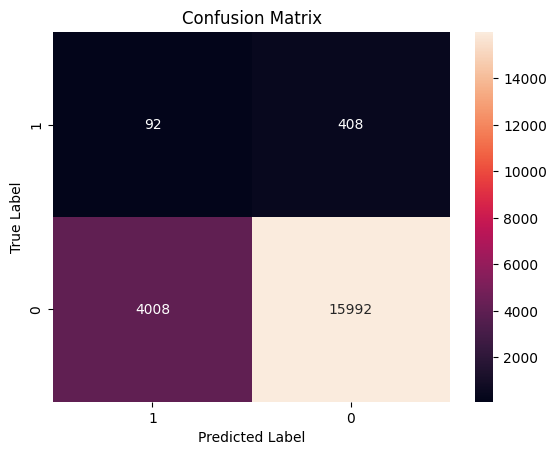

In [17]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score

f1_test = f1_score(y_test, anomalies)
precision_test = precision_score(y_test, anomalies)
recall_test = recall_score(y_test, anomalies)
accuracy_test = accuracy_score(y_test, anomalies)

print(f"F1 Score: {f1_test}\nPrecision: {precision_test}\nRecall: {recall_test}\nAccuracy: {accuracy_test}")

cm = confusion_matrix(y_test, anomalies)
plt.title("Confusion Matrix")
ax = sns.heatmap(cm, annot=True, fmt='0.0f')
ax.invert_yaxis()
ax.invert_xaxis()
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

# Predictions using enitre anomaly detector

## Computing threshold for anomaly detection

In [18]:
reconstructions = autoencoder.predict(x_test_scaled)

mse = np.mean(np.power(x_test_scaled - reconstructions, 2), axis=1)

641/641 ━━━━━━━━━━━━━━━━━━━━ 1s 926us/step


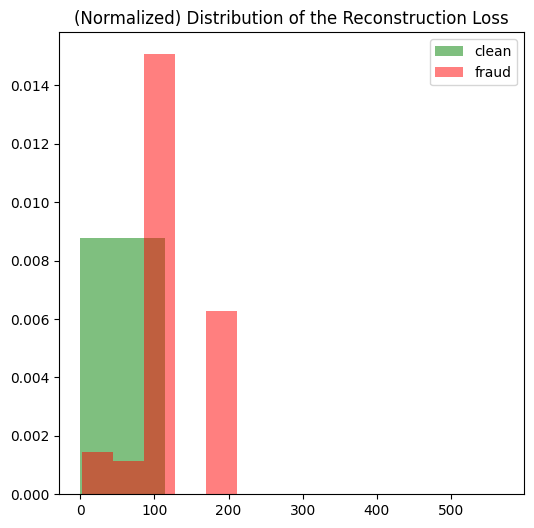

In [27]:
clean = mse[y_test==0]
fraud = mse[y_test==1]

fig, ax = plt.subplots(figsize=(6,6))

ax.hist(clean, bins=5, density=True, label="clean", alpha=.5, color="green")
ax.hist(fraud, bins=5, density=True, label="fraud", alpha=.5, color="red")

plt.title("(Normalized) Distribution of the Reconstruction Loss")
plt.legend()
plt.show()

In [20]:
def mad_score(points):
    """https://www.itl.nist.gov/div898/handbook/eda/section3/eda35h.htm """
    m = np.median(points)
    ad = np.abs(points - m)
    mad = np.median(ad)
    
    return 0.6745 * ad / mad

## Separating anomalies

In [36]:
THRESHOLD = 55
z_scores = mad_score(mse)

outliers = z_scores > THRESHOLD

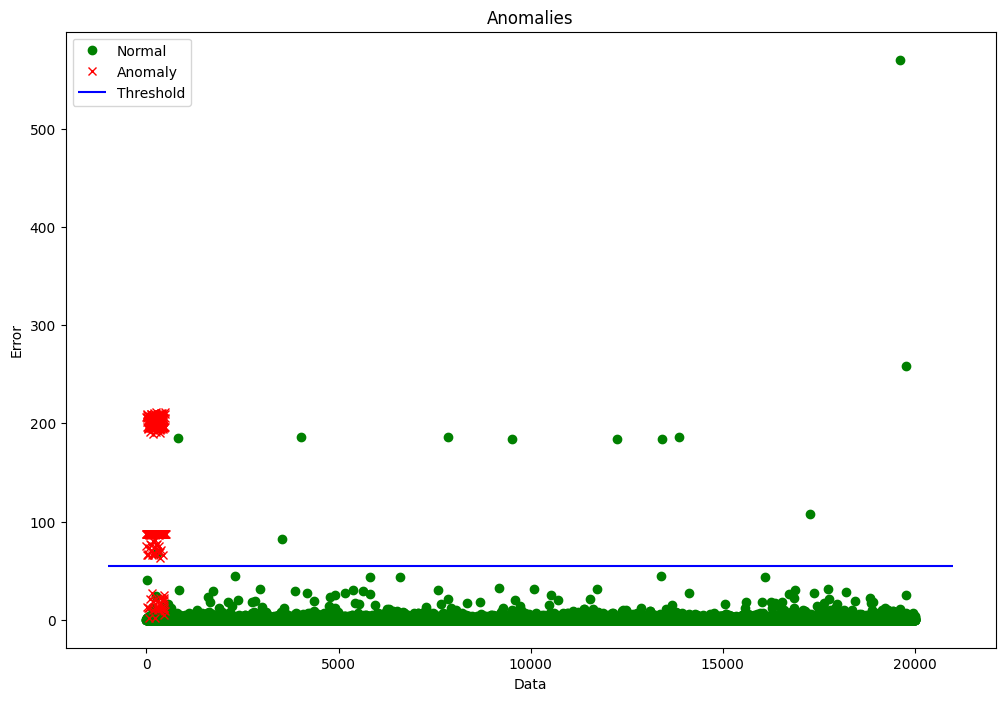

In [37]:
threshold = THRESHOLD
figure, axes = plt.subplots(figsize=(12, 8))
axes.plot(clean, marker='o', linestyle='',
                    color='g', label="Normal")
axes.plot(fraud, marker='x', linestyle='',
                    color='r', label="Anomaly")

axes.hlines(threshold, axes.get_xlim()[0], axes.get_xlim()[1], colors="b", zorder=100, label='Threshold')
axes.legend()

plt.title("Anomalies")
plt.ylabel("Distance")
plt.xlabel("Data")
plt.show()

## plots

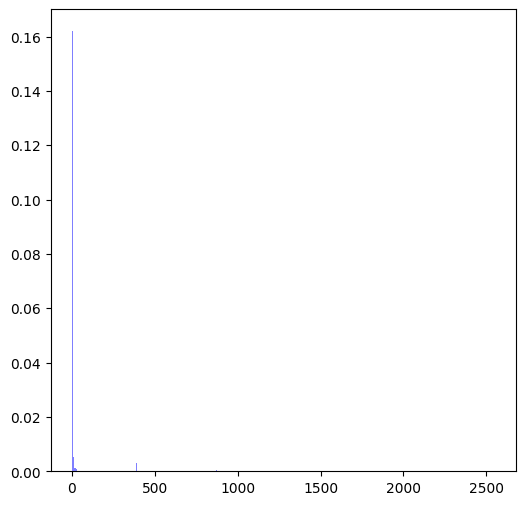

In [38]:
fig = plt.figure(figsize=(6,6))
plt.hist(z_scores, bins=500, density=True, alpha=0.5, color='blue')
plt.show()

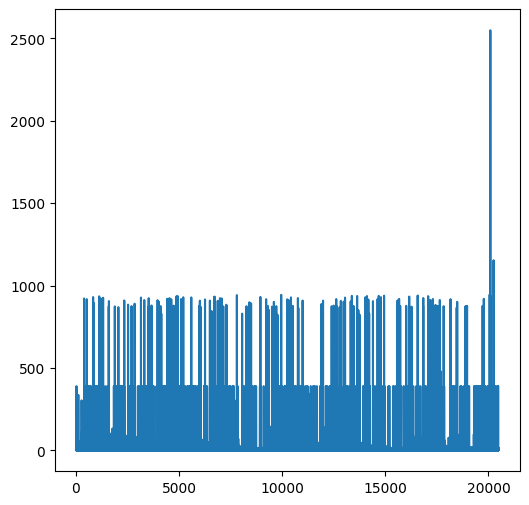

In [39]:
fig = plt.figure(figsize=(6,6))
plt.plot(z_scores)
plt.show()

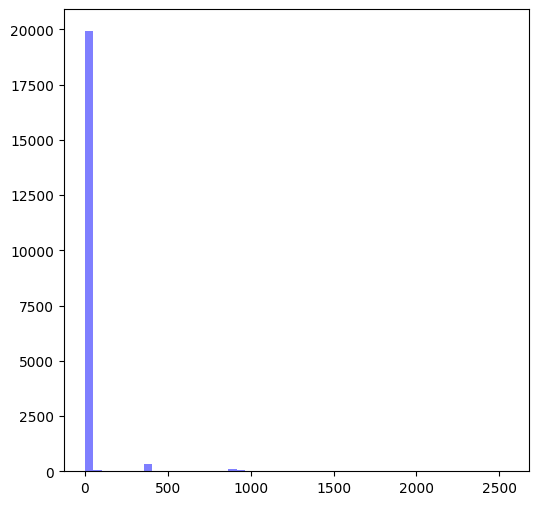

In [40]:
fig = plt.figure(figsize=(6,6))
plt.hist(z_scores, bins=50, alpha=0.5, color='blue')
plt.show()

## Evaluating

F1 Score: 0.9063670411985019
Precision: 0.852112676056338
Recall: 0.968
Accuracy: 0.9951219512195122


Text(50.722222222222214, 0.5, 'True Label')

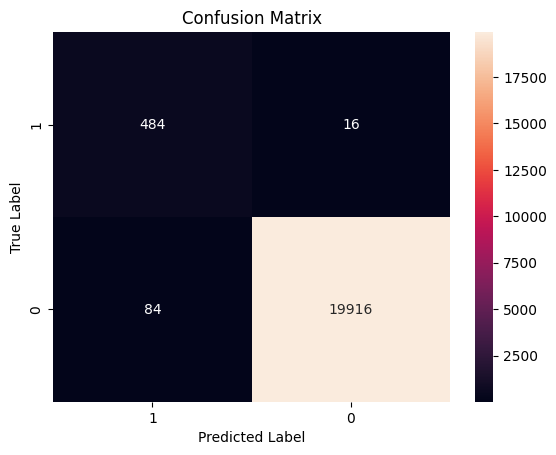

In [41]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score

f1_test = f1_score(y_test, outliers)
precision_test = precision_score(y_test, outliers)
recall_test = recall_score(y_test, outliers)
accuracy_test = accuracy_score(y_test, outliers)

print(f"F1 Score: {f1_test}\nPrecision: {precision_test}\nRecall: {recall_test}\nAccuracy: {accuracy_test}")

cm = confusion_matrix(y_test, outliers)
plt.title("Confusion Matrix")
ax = sns.heatmap(cm, annot=True, fmt='0.0f')
ax.invert_yaxis()
ax.invert_xaxis()
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

In [42]:
tn, fp, fn, tp = cm.ravel()
print("False Negative Rate:", fn/(fn+tn))
print("False Positive Rate:", fp/(fp+tp))

False Negative Rate: 0.0008027292795504716
False Positive Rate: 0.14788732394366197
